# Problema 2 — Estimación de Edad con CNNs
## Notebook 1 de 2: Preparación de Datos y DataLoaders

> **Referencia:** este notebook expande el ejemplo `age_regression_dataloader.ipynb` que ya conoces.  
> Ahí encontrarás el código completo de referencia — aquí tienes que construirlo tú paso a paso.

---

### ¿Qué haremos?

```
UTKFace/  (imágenes crudas, ~20k archivos)
    25_0_0_20170116.jpg
    32_1_2_20170210.jpg  ...
       │
       ▼
  Dividir en train / val / test      ← ya está dado
       │
       ▼
  🔧 Crear AgeDataset                
       │
       ▼
  🔧 Definir transformaciones        
       │
       ▼
  🔧 Crear los DataLoaders           
       │
       ▼
  Verificar y guardar                ← ya está dado
```

El notebook `P2_02_entrenamiento.ipynb` cargará los DataLoaders que defines aquí.

---
## 0. Importaciones y configuración

In [ ]:
import os
import re
import random
import shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# ── Configuración global ──────────────────────────────────────────────────────
# Intentar descargar el dataset con kagglehub si no existe localmente
import kagglehub

print("Descargando dataset UTKFace desde Kaggle...")
RAW_DIR = Path(kagglehub.dataset_download("jangedoo/utkface-new")) / "UTKFace"

DATA_DIR    = Path("dataset")    # destino con train/ val/ test/
IMG_SIZE    = 64                 # resolución de trabajo (64×64)
BATCH_SIZE  = 32
NUM_WORKERS = 2
SEED        = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
print(f"Dataset ubicado en: {RAW_DIR}")

c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📥 Descargando dataset UTKFace desde Kaggle...
✅ Dispositivo: cpu
✅ Dataset ubicado en: C:\Users\Usuario\.cache\kagglehub\datasets\jangedoo\utkface-new\versions\1\UTKFace


---
## 1. Preparar el dataset UTKFace

### Descarga

UTKFace contiene ~23,000 imágenes de rostros con la edad codificada en el nombre de archivo.

**Formato:** `[age]_[gender]_[race]_[datetime].jpg`  
**Ejemplo:** `25_0_2_20170116174525125.jpg` → edad = 25

Descarga el dataset en Kaggle: https://www.kaggle.com/datasets/jangedoo/utkface-new  
Descomprime y coloca las imágenes directamente en la carpeta `UTKFace/`.

```
UTKFace/
  1_0_0_20161219203650533.jpg
  1_0_0_20161219222832135.jpg
  ...
```

In [11]:

# ── Verificar que las imágenes están disponibles ──────────────────────────────
EXTENSIONS = {".jpg", ".jpeg", ".png"}

all_images = [
    p for p in RAW_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in EXTENSIONS
]

if len(all_images) == 0:
    raise FileNotFoundError(
        f"No se encontraron imágenes en '{RAW_DIR}'.\n"
        "Descarga UTKFace de Kaggle y coloca las imágenes en esa carpeta."
    )

print(f"Total imágenes encontradas: {len(all_images):,}")
print(f"Ejemplo de nombre: {all_images[0].name}")


Total imágenes encontradas: 23,708
Ejemplo de nombre: 100_0_0_20170112213500903.jpg.chip.jpg


In [ ]:

# ── División 70 / 15 / 15 (solo se ejecuta si dataset/ no existe) ─────────────
if not (DATA_DIR / "train").exists():
    random.seed(SEED)
    random.shuffle(all_images)

    n = len(all_images)
    n_train = int(n * 0.70)
    n_val   = int(n * 0.15)

    splits = {
        "train" : all_images[:n_train],
        "val"   : all_images[n_train : n_train + n_val],
        "test"  : all_images[n_train + n_val :],
    }

    for split_name, files in splits.items():
        dest = DATA_DIR / split_name
        dest.mkdir(parents=True, exist_ok=True)
        print(f"Copiando {split_name}: {len(files):,} imágenes...")
        for src in files:
            shutil.copy2(src, dest / src.name)
    print(" División completada")
else:
    print(" dataset/ ya existe — saltando división")

for split_name in ["train", "val", "test"]:
    count = sum(1 for f in (DATA_DIR / split_name).iterdir()
                if f.suffix.lower() in EXTENSIONS)
    print(f"  {split_name:6s}: {count:,} imágenes")

✅ dataset/ ya existe — saltando división
  train : 16,595 imágenes
  val   : 3,556 imágenes
  test  : 3,557 imágenes


---
## 2. Exploración del dataset

Antes de programar el Dataset, exploramos las imágenes y la distribución de edades.

Edades — min: 1, max: 116, media: 33.3, mediana: 29


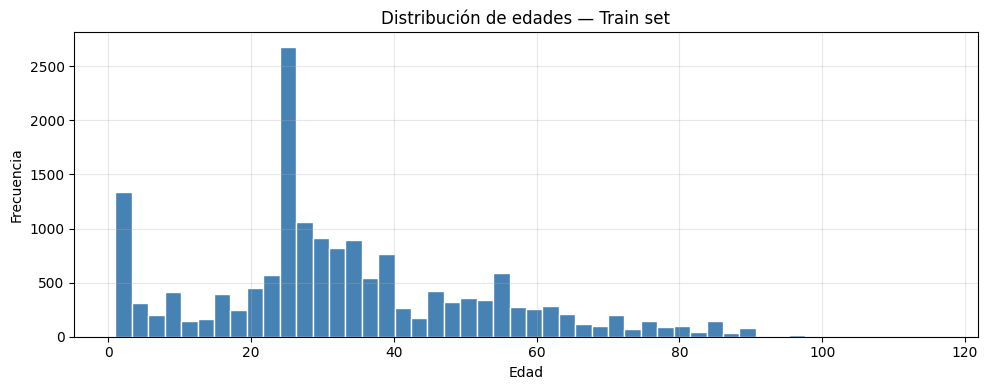


 ¿Notas algún desbalance? ¿Qué rangos tienen más muestras?


In [13]:
# ── Distribución de edades en train ──────────────────────────────────────────
train_files = list((DATA_DIR / "train").iterdir())

ages = []
for p in train_files:
    match = re.match(r'^(\d+)_', p.name)
    if match:
        age = int(match.group(1))
        if 0 <= age <= 116:
            ages.append(age)

ages = np.array(ages)
print(f"Edades — min: {ages.min()}, max: {ages.max()}, media: {ages.mean():.1f}, mediana: {np.median(ages):.0f}")

plt.figure(figsize=(10, 4))
plt.hist(ages, bins=50, color="steelblue", edgecolor="white")
plt.title("Distribución de edades — Train set")
plt.xlabel("Edad"); plt.ylabel("Frecuencia")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n ¿Notas algún desbalance? ¿Qué rangos tienen más muestras?")

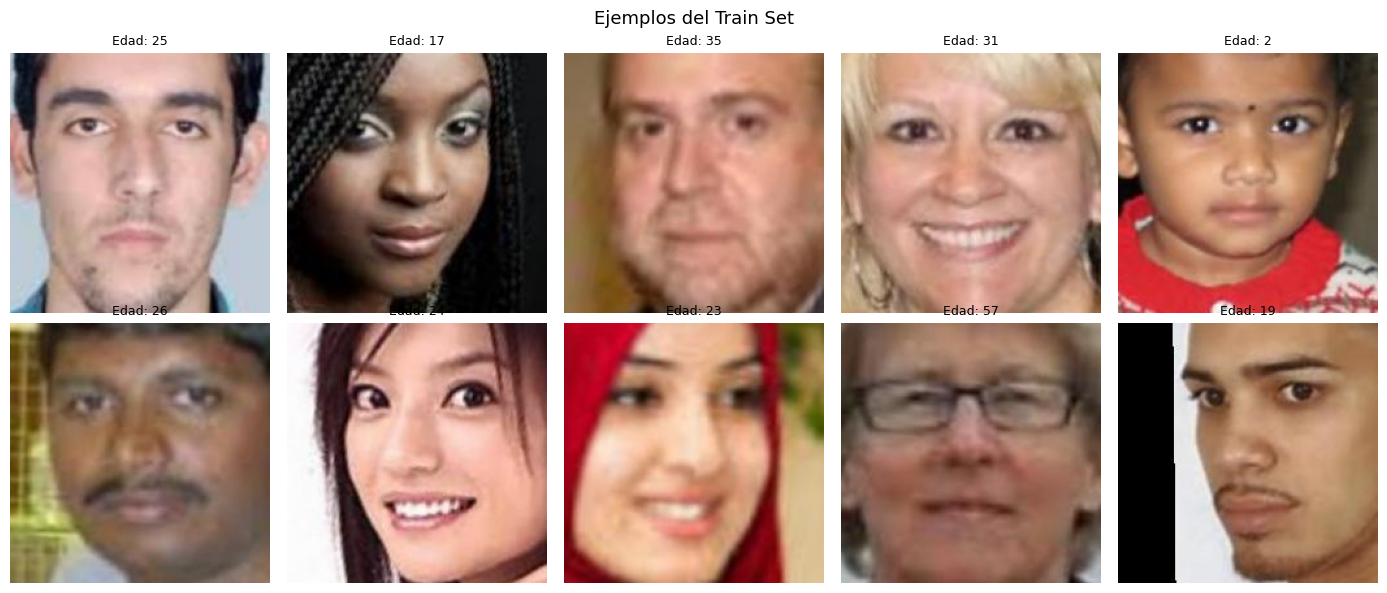

In [14]:
# ── Visualizar imágenes de ejemplo ───────────────────────────────────────────
sample_files = random.sample(train_files, 10)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Ejemplos del Train Set", fontsize=13)

for ax, p in zip(axes.flat, sample_files):
    match = re.match(r'^(\d+)_', p.name)
    age = int(match.group(1)) if match else -1
    ax.imshow(Image.open(p).convert("RGB"))
    ax.set_title(f"Edad: {age}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

---
## 3. Implementar `AgeDataset`

### Los 3 métodos obligatorios de `torch.utils.data.Dataset`

| Método | ¿Para qué sirve? |
|--------|------------------|
| `__init__` | Construye la lista de rutas + etiquetas. **No carga imágenes.** |
| `__len__` | Retorna el número total de ejemplos |
| `__getitem__(idx)` | Carga **una** imagen del disco y retorna `(tensor, edad_float)` |

> **Regla de oro:** `__init__` solo guarda metadatos.  
> Solo `__getitem__` toca el disco — y únicamente cuando PyTorch lo pide.

---

In [15]:
class AgeDataset(Dataset):
    """
    Dataset para imágenes con etiqueta de edad en el nombre de archivo.
    Formato esperado: [age]_[gender]_[race]_[datetime].jpg
    Ejemplo:          25_0_2_20170116174525125.jpg
    """

    def __init__(self, root_dir: Path, transform=None):
        """
        Args:
            root_dir  : ruta a la carpeta (ej: dataset/train)
            transform : transformaciones a aplicar a cada imagen
        """
        self.transform = transform

        # ── Paso 1: recolectar rutas y parsear etiquetas ───────────────────────
        # Esto ocurre UNA SOLA VEZ al crear el dataset.
        # Solo guardamos strings/números en memoria, NO píxeles.
        EXTENSIONS = {".jpg", ".jpeg", ".png"}
        self.samples = []  # lista de tuplas (path, age_float)

        for img_path in Path(root_dir).iterdir():
            if img_path.suffix.lower() not in EXTENSIONS:
                continue
            age = self._parse_age(img_path.name)
            if age is not None:            # descarta archivos con nombre inválido
                self.samples.append((img_path, float(age)))

        print(f"  [{root_dir.name}] {len(self.samples):,} imágenes cargadas")

    @staticmethod
    def _parse_age(filename: str):
        """
        Extrae la edad del nombre de archivo.
        '25_0_2_20170116.jpg'  →  25
        Retorna None si el formato no coincide.
        """
        match = re.match(r'^(\d+)_', filename)
        if match:
            age = int(match.group(1))
            if 0 <= age <= 116:            # filtro de sanidad
                return age
        return None

    # ── Los 2 métodos obligatorios ─────────────────────────────────────────────

    def __len__(self):
        """PyTorch llama esto para saber cuántos ejemplos hay."""
        return len(self.samples)

    def __getitem__(self, idx):
        """
        PyTorch llama esto para obtener el ejemplo número `idx`.
        Este es el único momento en que tocamos el disco.

        Retorna:
            image  : Tensor [C, H, W]  (float32)
            age    : Tensor escalar     (float32)
        """
        img_path, age = self.samples[idx]

        # Leer imagen del disco
        image = Image.open(img_path).convert("RGB")

        # Aplicar transformaciones (resize, normalizar, augmentations...)
        if self.transform:
            image = self.transform(image)

        # La etiqueta debe ser float32 para regresión con MSELoss
        return image, torch.tensor(age, dtype=torch.float32)
        # ----------------------


# ── Tests ─────────────────────────────────────────────────────────────────────
_tmp_t = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])
_ds = AgeDataset(DATA_DIR / "train", transform=_tmp_t)

assert isinstance(len(_ds), int),                 "__len__ debe retornar int"
img, age = _ds[0]
assert img.shape == (3, IMG_SIZE, IMG_SIZE),       f"Shape incorrecto: {img.shape}"
assert img.dtype == torch.float32,                 "imagen debe ser float32"
assert age.dtype == torch.float32,                 "edad debe ser float32"
assert 0 <= age.item() <= 116,                     "edad fuera de rango"

print(" AgeDataset pasa todos los tests")
print(f"   Ejemplo 0: shape={img.shape}, edad={age.item():.0f} años")

  [train] 16,595 imágenes cargadas
 AgeDataset pasa todos los tests
   Ejemplo 0: shape=torch.Size([3, 64, 64]), edad=100 años


---
## 4. Definir las transformaciones

Las transformaciones se aplican dentro de `__getitem__`, imagen a imagen, justo antes de entregarla al modelo.

```
Imagen en disco  →  transform  →  Tensor normalizado
```

| Set | ¿Por qué diferente? |
|-----|--------------------|
| **Train** | Incluye *data augmentation* — el modelo ve variantes artificiales cada época |
| **Val / Test** | Sin augmentation — evaluación limpia y reproducible |

**Normalización ImageNet** (usada cuando el modelo fue pre-entrenado en ImageNet):
```
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]
```

---


In [16]:
# Valores de media y std de ImageNet (estándar para modelos pre-entrenados)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Transformación para ENTRENAMIENTO ─────────────────────────────────────────
# Incluye augmentations para que el modelo vea variedad artificial
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),   # redimensionar a 64×64
    transforms.RandomHorizontalFlip(p=0.5),   # espejo horizontal aleatorio
    transforms.ColorJitter(                   # variaciones de color leves
        brightness=0.2, contrast=0.2),
    transforms.ToTensor(),                    # PIL Image [H,W,C] → Tensor [C,H,W], valores [0,1]
    transforms.Normalize(IMAGENET_MEAN,       # normalizar con media/std de ImageNet
                         IMAGENET_STD),
])

# ── Transformación para VALIDACIÓN y TEST ─────────────────────────────────────
# Sin augmentation: queremos evaluar con datos limpios y consistentes
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print("Transformaciones definidas ✓")
print(f"  Train: Resize → Flip → ColorJitter → ToTensor → Normalize")
print(f"  Val  : Resize → ToTensor → Normalize")

assert len(train_transform.transforms) > len(val_transform.transforms), \
    "train_transform debe tener más pasos que val_transform"

print("Transformaciones ✓")
print("  Train:", " → ".join(type(t).__name__ for t in train_transform.transforms))
print("  Val  :", " → ".join(type(t).__name__ for t in val_transform.transforms))

Transformaciones definidas ✓
  Train: Resize → Flip → ColorJitter → ToTensor → Normalize
  Val  : Resize → ToTensor → Normalize
Transformaciones ✓
  Train: Resize → RandomHorizontalFlip → ColorJitter → ToTensor → Normalize
  Val  : Resize → ToTensor → Normalize


---
## 5. Crear los Datasets

In [17]:
print("Construyendo datasets...")
train_dataset = AgeDataset(DATA_DIR / "train", transform=train_transform)
val_dataset   = AgeDataset(DATA_DIR / "val",   transform=val_transform)
test_dataset  = AgeDataset(DATA_DIR / "test",  transform=val_transform)

total = len(train_dataset) + len(val_dataset) + len(test_dataset)
print(f"\nTotal: {total:,} imágenes")

Construyendo datasets...
  [train] 16,595 imágenes cargadas
  [val] 3,556 imágenes cargadas
  [test] 3,557 imágenes cargadas

Total: 23,708 imágenes


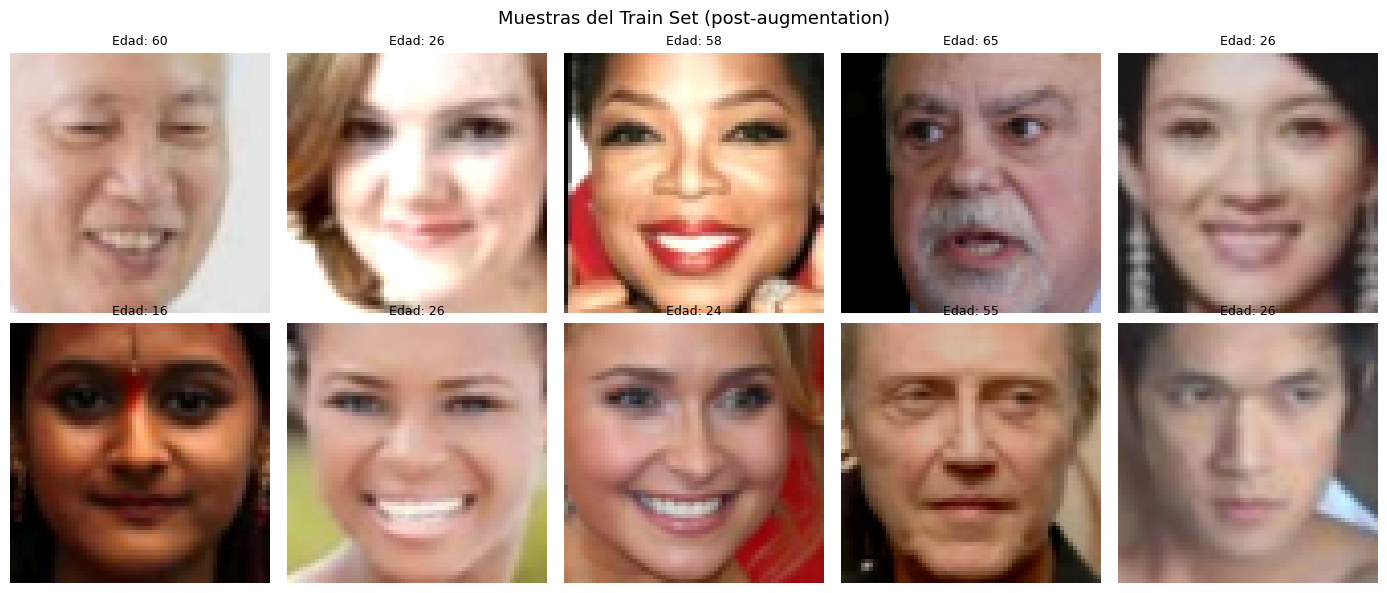

In [18]:
# ── Visualizar muestras (con denormalización para poder verlas) ───────────────
def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    m = torch.tensor(mean).view(3, 1, 1)
    s = torch.tensor(std).view(3, 1, 1)
    return (tensor * s + m).clamp(0, 1)


indices = np.random.choice(len(train_dataset), 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Muestras del Train Set (post-augmentation)", fontsize=13)

for ax, idx in zip(axes.flat, indices):
    img_t, age = train_dataset[idx]
    ax.imshow(denormalize(img_t).permute(1, 2, 0).numpy())
    ax.set_title(f"Edad: {int(age.item())}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

---
## 6. Crear los DataLoaders

### Parámetros clave

| Parámetro | ¿Qué controla? | Regla |
|-----------|----------------|-------|
| `batch_size` | Imágenes por lote | 32–64 |
| `shuffle` | Mezcla antes de cada época | `True` **solo** en train |
| `num_workers` | Procesos paralelos de lectura | 2–8 |
| `pin_memory` | Optimiza transferencia CPU→GPU | `True` si hay CUDA |
| `drop_last` | Descarta el último batch incompleto | Opcional en train |

---

### Crea los tres DataLoaders

In [19]:
train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,         # ← IMPORTANTE en train: mezcla cada época
    num_workers = NUM_WORKERS,  # lectura paralela del disco
    pin_memory  = DEVICE.type == "cuda",  # acelera transferencia CPU→GPU
    drop_last   = True,         # descarta el último batch si es menor a BATCH_SIZE
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,        # ← NUNCA mezclar en val/test
    num_workers = NUM_WORKERS,
    pin_memory  = DEVICE.type == "cuda",
)

test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = DEVICE.type == "cuda",
)

# ── Información útil ──────────────────────────────────────────────────────────
print("DataLoaders creados ✓")

assert train_loader is not None, "Define train_loader"
assert val_loader   is not None, "Define val_loader"
assert test_loader  is not None, "Define test_loader"

print("DataLoaders creados ✓")
print(f"  train_loader : {len(train_loader)} batches × {BATCH_SIZE} imgs")
print(f"  val_loader   : {len(val_loader)} batches × {BATCH_SIZE} imgs")
print(f"  test_loader  : {len(test_loader)} batches × {BATCH_SIZE} imgs")

DataLoaders creados ✓
DataLoaders creados ✓
  train_loader : 518 batches × 32 imgs
  val_loader   : 112 batches × 32 imgs
  test_loader  : 112 batches × 32 imgs


In [ ]:
# ── Inspeccionar un batch ─────────────────────────────────────────────────────
batch_imgs, batch_ages = next(iter(train_loader))

print("=== Un batch del DataLoader ===")
print(f"  batch_imgs.shape : {batch_imgs.shape}")
print(f"                      └─ [batch={BATCH_SIZE}, canales=3, H={IMG_SIZE}, W={IMG_SIZE}]")
print(f"  batch_ages.shape : {batch_ages.shape}")
print(f"                      └─ [batch={BATCH_SIZE}] — una edad por imagen")
print(f"  Edades en el batch: {batch_ages[:8].int().tolist()} ...")

---
## 7. Guardar los DataLoaders

In [ ]:
torch.save({
    "train_loader"  : train_loader,
    "val_loader"    : val_loader,
    "test_loader"   : test_loader,
    "img_size"      : IMG_SIZE,
    "batch_size"    : BATCH_SIZE,
    "imagenet_mean" : IMAGENET_MEAN,
    "imagenet_std"  : IMAGENET_STD,
}, "dataloaders_utk.pth")

print(" DataLoaders guardados en dataloaders_utk.pth")
print("   Abre P2_02_entrenamiento.ipynb para entrenar la CNN.")

 DataLoaders guardados en dataloaders_utk.pth
   Abre P2_02_entrenamiento.ipynb para entrenar la CNN.


---
## 8. Preguntas de reflexión

1. En `AgeDataset.__init__`, ¿por qué guardamos solo las **rutas** en memoria y no las imágenes cargadas?  
   ¿Qué problema tendríamos con 20,000 imágenes de 200×200 píxeles?
  Guardamos solo las rutas para no cargar todas las imágenes en memoria al mismo tiempo. Si cargara las 20,000 imágenes de 200×200, consumiría demasiada RAM y podría hacer que el sistema se vuelva lento o incluso falle.

2. ¿Qué ocurre si usas `shuffle=True` en `val_loader`? ¿Cambia el resultado del modelo?
Si uso shuffle=True en el val_loader, solo cambia el orden en que se evaluan los datos, pero no cambia el resultado final del modelo. La métrica será la misma, solo que calculada en diferente orden.

3. Ejecuta la celda de visualización de muestras dos veces seguidas. ¿Las imágenes cambian?  
   ¿Por qué sí o por qué no? ¿Qué tiene que ver con las augmentations?
   si, las imágenes pueden cambiar entre ejecuciones porque estoy usando data augmentation en el conjunto de entrenamiento. Transformaciones como RandomHorizontalFlip hacen que cada vez se vean versiones diferentes de la misma imagen.

4. Observa el histograma de edades. El dataset tiene muchas más fotos de personas entre 20–40 años.  
   ¿Cómo crees que esto afectará el error del modelo según el rango de edad?
  creemos que el modelo tendrá menor error en edades entre 20 y 40 porque hay más datos en ese rango. En cambio, tendrá mayor error en edades con menos ejemplos, porque aprende menos sobre ellas.